# Tarea 2

Instrucciones

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a juancaros@udec.cl el dia 20/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion.

El archivo a utilizar es panel_eps.csv, que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud.

In [206]:
#Cargamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
import linearmodels.panel as lmp
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings("ignore")

%matplotlib inline

# Descripción de la data y limpieza
1.-Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

**R**: Cargamos la data y se analizan sus variables, vemos estadísticas descriptivas, los tipos de variables y realizamos las limpiezas correspondientes

In [207]:
#Cargamos la data
url = "https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/panel_eps.csv"
df=pd.read_csv(url)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96846 entries, 0 to 96845
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folio_n20   96846 non-null  int64  
 1   year        96846 non-null  int64  
 2   time        96846 non-null  int64  
 3   edad        96846 non-null  int64  
 4   hombre      96796 non-null  float64
 5   edu         92920 non-null  float64
 6   region      80848 non-null  float64
 7   status      96736 non-null  float64
 8   kids        96846 non-null  int64  
 9   children    78017 non-null  float64
 10  situation   96846 non-null  int64  
 11  lmp         96846 non-null  int64  
 12  exp         84869 non-null  float64
 13  size        29044 non-null  float64
 14  occupation  49777 non-null  float64
 15  wage        53897 non-null  float64
 16  hours       54576 non-null  float64
 17  informal    41259 non-null  float64
 18  selfemp     55502 non-null  float64
 19  publicemp   55502 non-nul

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,...,0.0,0.0,0.0,0.0,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,...,NaN,NaN,NaN,NaN,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,...,NaN,NaN,NaN,NaN,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,...,NaN,NaN,NaN,NaN,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


In [208]:
# Eliminamos columnas vacías, agregamos size por su gran porcentaje de NaN

df = df.drop(columns=["fondoa", "fondob", "fondoc", "fondod", "fondoe","size"], errors="ignore")

# Eliminamos periodos 1 y 6 que producen problemas con enfermedades
df = df[~df['time'].isin([1, 6])]
# Estandarizamos wage por sus valores de alto rango y no tener problemas
df['wage'] = np.log(df['wage'] + 1)  # +1 evita log(0)
# Corregimos variable assets
df["assets"] = df["assets"].replace(",", "", regex=True)
df["assets"] = pd.to_numeric(df["assets"], errors="coerce")
df=df.rename(columns={"folio_n20":"ID"})
df['assets'] = np.log(df['assets'] + 1)
# Corregimos edad si está como año de nacimiento
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
cond_nacimiento = df["edad"] > 1000
df.loc[cond_nacimiento, "edad"] = (2000 + df.loc[cond_nacimiento, "year"]) - df.loc[cond_nacimiento, "edad"]

# Rellenamos region usando ID
df["region"] = df.groupby("ID")["region"].transform(lambda x: x.ffill().bfill())

df

,ID,year,time,edad,hombre,edu,region,status,kids,children,...,publicemp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,0.0,0.0,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,0.0,0.0,0.0,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,1.0,0.0,0.0,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,5.0,5.0,0,0.0,...,0.0,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
5,124560205935,4,2,20,0.0,15.0,13.0,3.0,1,3.0,...,NaN,1.0,0.0,0.0,21,70.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,20,0.0,16.0,NaN,3.0,0,0.0,...,NaN,1.0,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,20,0.0,12.0,NaN,2.0,0,0.0,...,0.0,1.0,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,20,0.0,15.0,NaN,5.0,0,0.0,...,NaN,1.0,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,20,0.0,8.0,NaN,2.0,0,0.0,...,1.0,1.0,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0


In [209]:
# vemos la cantidad de nulos en %
missing_sorted = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print(missing_sorted)  

informal      58.17
occupation    52.62
wage          45.48
hours         44.72
publicemp     43.22
selfemp       43.22
assets        25.14
sistema       25.13
expectancy    14.71
children      12.87
exp           10.66
region        10.38
cotizando      7.29
edu            1.49
illness        0.20
status         0.13
hombre         0.06
exp_sist       0.00
cronica        0.00
nocronica      0.00
ID             0.00
year           0.00
lmp            0.00
situation      0.00
kids           0.00
edad           0.00
time           0.00
mental         0.00
dtype: float64


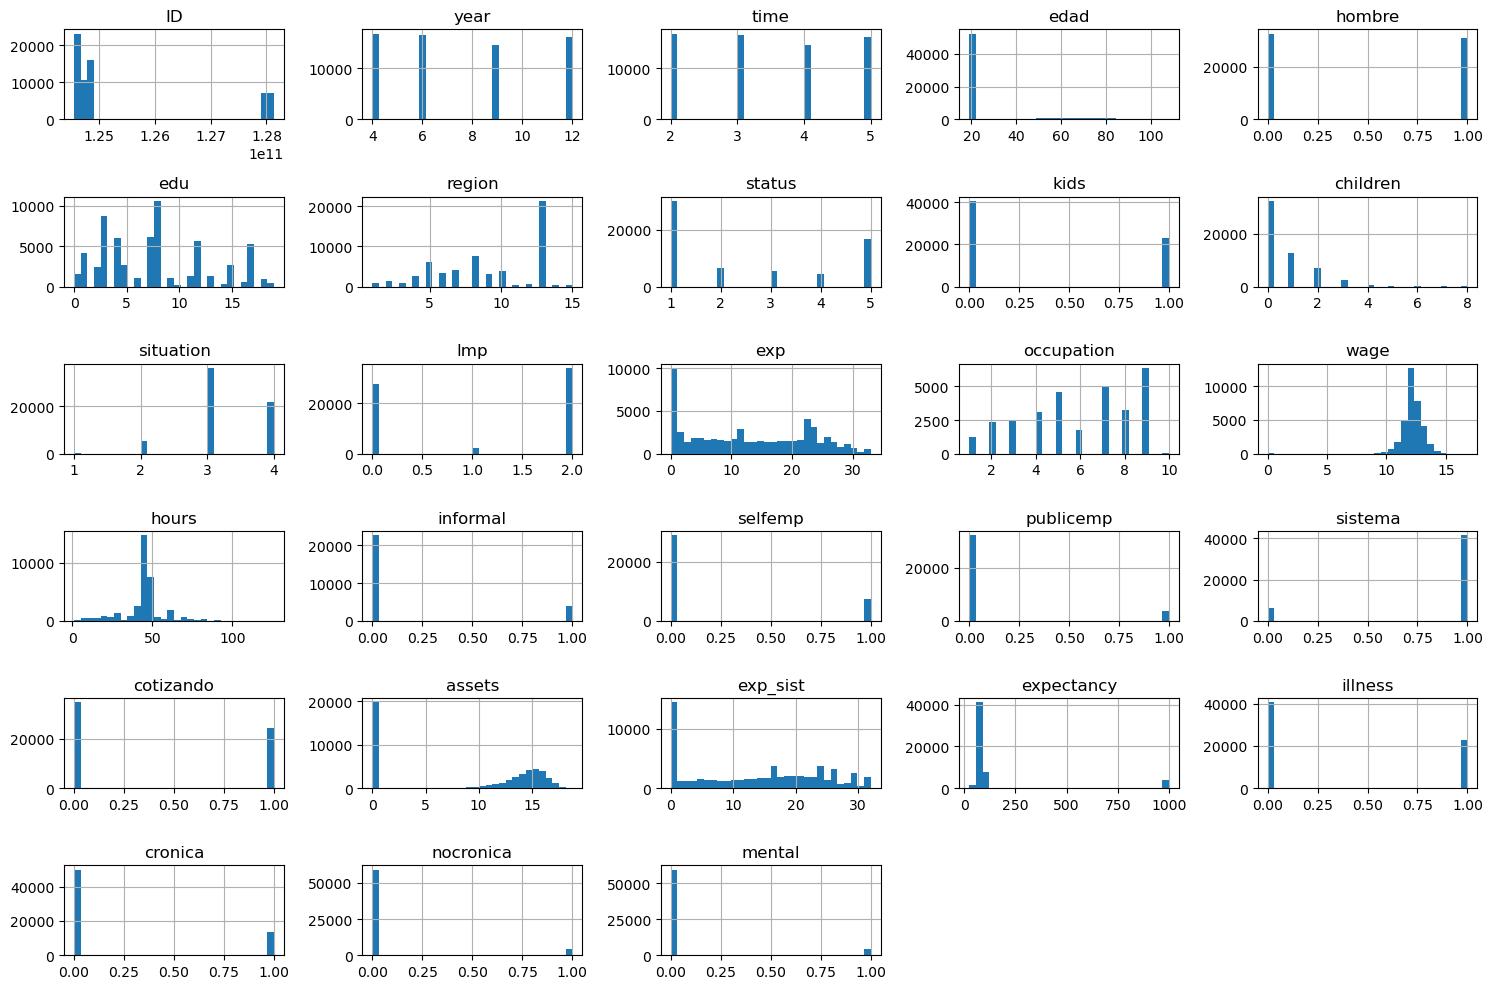

In [210]:
#Visulizamos las distribuciones de las variables
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [214]:
# Corregimos posibles outliers
Q1 = df['expectancy'].quantile(0.25)
Q3 = df['expectancy'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['expectancy'] >= (Q1 - 1.5*IQR)) & (df['expectancy'] <= (Q3 + 1.5*IQR))]


# Creamos variables indicadores para las variables que dependen del empleo
cols_indicador = ['assets', 'sistema', 'edu', 'wage', 'hours', 'exp', 'cronica', 'nocronica', 'illness', 'mental']
for col in cols_indicador:
    df[f'missing_{col}'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(0)

# Imputamos las variables relacionadas al empleo, condiciandas a si la presona cuenta con empleo
employment_vars = ['wage', 'hours', 'exp', 'informal', 'selfemp', 'publicemp']
employed_mask = (df['situation'] == 3)

# Imputamos con mediana y moda
for var in employment_vars:
    if var in ['wage', 'hours', 'exp']:
        median_val = df.loc[employed_mask, var].median()
        df.loc[employed_mask & df[var].isna(), var] = median_val
    else:
        mode_val = df.loc[employed_mask, var].mode()[0] if not df.loc[employed_mask, var].mode().empty else 0
        df.loc[employed_mask & df[var].isna(), var] = mode_val
    
      # Para no empleados asignamos 0
    not_employed_mask = (df['situation'] != 3)
    df.loc[not_employed_mask, var] = 0

# Verfificamos valores nulos
print(df.isna().mean().sort_values(ascending=False))

occupation           0.511129
children             0.129150
region               0.117025
cotizando            0.059880
status               0.000965
hombre               0.000462
ID                   0.000000
illness              0.000000
cronica              0.000000
nocronica            0.000000
mental               0.000000
missing_assets       0.000000
missing_sistema      0.000000
missing_wage         0.000000
missing_edu          0.000000
exp_sist             0.000000
missing_hours        0.000000
missing_exp          0.000000
missing_cronica      0.000000
missing_nocronica    0.000000
missing_illness      0.000000
expectancy           0.000000
sistema              0.000000
assets               0.000000
year                 0.000000
publicemp            0.000000
selfemp              0.000000
informal             0.000000
hours                0.000000
wage                 0.000000
exp                  0.000000
lmp                  0.000000
situation            0.000000
kids      

In [215]:
# Creamos variables dummies para las variables categóricas
categorical_vars = ["status","situation","lmp","region","occupation"]
df = pd.get_dummies(df,columns=categorical_vars, prefix=categorical_vars,drop_first=True)
#Verificamos NaN
print(df.isna().mean().sort_values(ascending=False))

children             0.129150
cotizando            0.059880
hombre               0.000462
ID                   0.000000
region_2.0           0.000000
                       ...   
missing_exp          0.000000
missing_cronica      0.000000
missing_nocronica    0.000000
missing_illness      0.000000
occupation_10.0      0.000000
Length: 65, dtype: float64


In [216]:
# Vemos el porcentaje de outliers
outlier_counts = {}

numeric_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if not col.startswith("missing_")
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)
outlier_counts = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))
for k, v in outlier_counts.items():
    print(f"{k}: {(v / len(df)) * 100:.2f}% outliers")

edad: 25.66% outliers
ID: 24.89% outliers
cronica: 20.69% outliers
selfemp: 11.39% outliers
mental: 6.71% outliers
nocronica: 6.56% outliers
informal: 6.52% outliers
publicemp: 6.31% outliers
expectancy: 5.95% outliers
children: 5.57% outliers
hours: 0.07% outliers
year: 0.00% outliers
time: 0.00% outliers
hombre: 0.00% outliers
edu: 0.00% outliers
kids: 0.00% outliers
exp: 0.00% outliers
wage: 0.00% outliers
sistema: 0.00% outliers
cotizando: 0.00% outliers
assets: 0.00% outliers
exp_sist: 0.00% outliers
illness: 0.00% outliers


# Pooled OLS
2.-Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

**R**: Para la regresión revisamo correlaciones entre las variables con una matriz de correlaciones. Para este modelo se ocuparán todas las variables excepto la dependiente y las que tiene una alta correlación entre ellas. La capacidad explicativa de este modelo es limitada (4.4%), destacan las variables sistema y missing_sistema con efectos negativos en la variable dependiente, dismunyendo en aproximadamente 4 años si es que aumenta en una unidad cada uno, por otro lado las variables que destacan por afectar positivamente la variable dependiente son status_4 y missing_assets, aumentando en 4 y 2 años respectivamente, en donde se puede interpretar según este modelo que ser viudo/a aumenta la expectativa de vida, al igual que no responder la variable assets, aunque esto ultimo tiene que ver más con la forma que tiene la data. Y cabe destcar que los hombres, según este modelo, viven 1.6 años más que las mujeres.

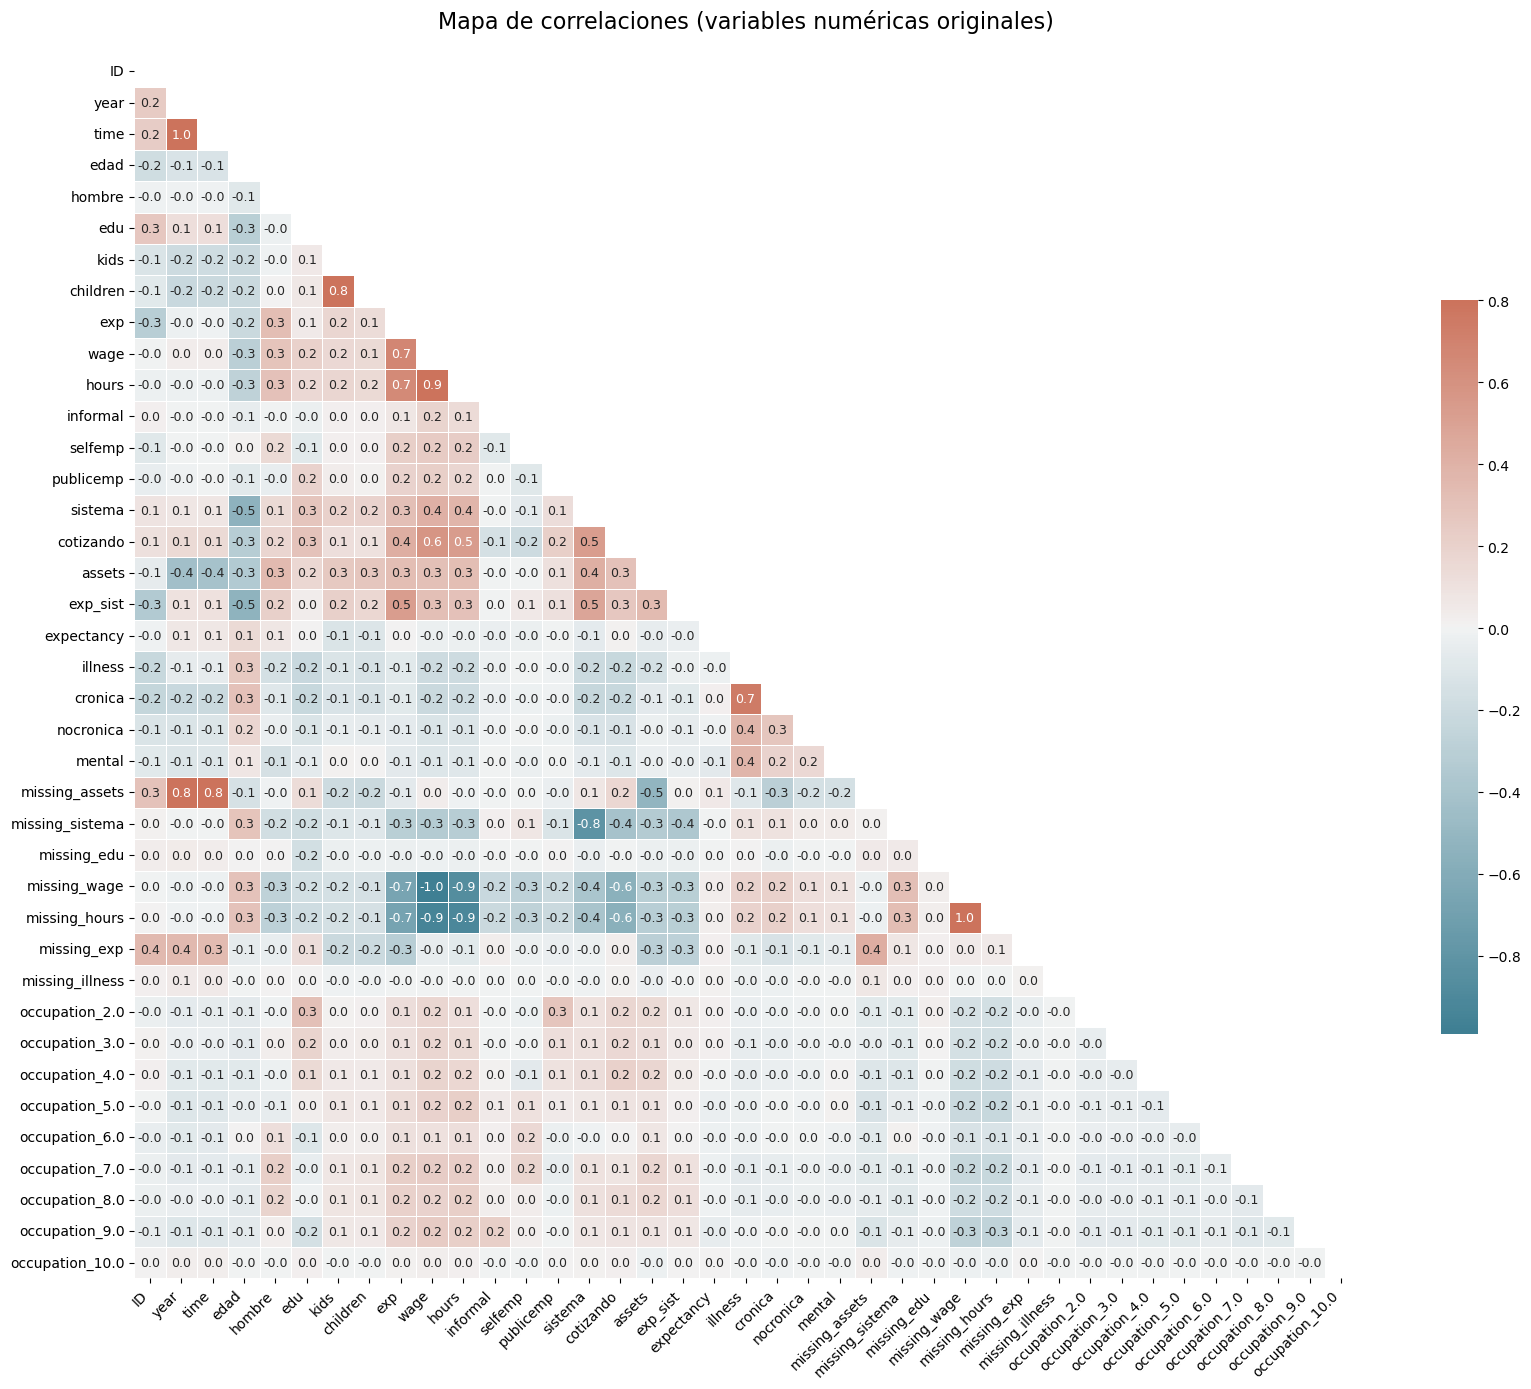

In [217]:
numeric_cols = [
    col for col in df.select_dtypes(include='number').columns 
    if not col.startswith("_isnull") 
    and not any(col.startswith(dummy_prefix) for dummy_prefix in ["status_", "situation_", "lmp_", "region_", "occ_"])
]
numeric_cols = [col for col in numeric_cols if df[col].nunique() > 1]
corr = df[numeric_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr,mask=mask,cmap=cmap,vmax=0.8,center=0,square=True,linewidths=0.5,cbar_kws={"shrink": 0.6},
            annot=True,fmt=".1f",annot_kws={"size": 9})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Mapa de correlaciones (variables numéricas originales)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [218]:
df = df.set_index(["ID","time"])

In [219]:
# Definimos variables
#df=df.dropna()
y = df['expectancy']
X = df[["wage","exp","assets","edu","sistema","hours","mental","illness",
        "cronica","nocronica","missing_assets","missing_sistema","missing_edu",
        "missing_hours","occupation_2.0","occupation_3.0","occupation_4.0",
        "occupation_5.0","occupation_6.0","occupation_7.0","occupation_8.0",
        "occupation_9.0","occupation_10.0","region_2.0", "region_3.0", "region_4.0", 
        "region_6.0", "region_7.0", "region_9.0", "region_10.0", "region_11.0", 
        "region_13.0", "region_14.0", "region_15.0","status_2.0","status_3.0",
        "status_4.0","status_5.0","hombre"
]]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
results = model.fit()
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0488
Estimator:                   PanelOLS   R-squared (Between):              0.0646
No. Observations:               49710   R-squared (Within):               0.0055
Date:                Tue, May 20 2025   R-squared (Overall):              0.0488
Time:                        19:17:11   Log-likelihood                -1.836e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      65.342
Entities:                       23846   P-value                           0.0000
Avg Obs:                       2.0846   Distribution:                F(39,49670)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             65.342
                            

# Efectos Fijos

3.-Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

**R**: Para este model se usaron las variables que tiene un p-value significativo del modelo anterior, y se eliminaron variables que causaban errrores porque causaban que el modelo absorviera la mayoría de variables. En este caso se usaron la mayor cantidad de variables para obtener un mejor modelo, eliminadno variables con alta correlaciones y con NaN de alto porcentaje. Para este modelo se verificó la multicolinealidad de las variables para no icluirlas en el modelo, también se excluyeron las variables con un valor p mayor a 0.1 del modelo anterior. La capacidad explicativa de este modelo es aún menor al del anterior (2.37%), además la mayoría de valores de p-values de cada variable son altos, por lo que son pocos signifcativos. Algunas variables que se pueden destacar son ocupattion_6 y missing_assets, las cuales son significativas y afectan de forma negativa y postiva respectivamente, disminuyendo en 1.4 años la expectativas de vida. En cocnlusión este modelo no muy poco siginificativo, pos los altos valores de p-value, y por un r^2 bastante bajo.

In [232]:
y = df["expectancy"]
X_= df[["exp","assets","edu","sistema","mental","illness",
        "cronica","missing_assets","missing_sistema",
        "occupation_2.0","occupation_3.0",
        "occupation_5.0","occupation_6.0","occupation_7.0","occupation_8.0",
        "occupation_9.0","region_2.0", "region_4.0", 
        "region_6.0", "region_9.0", "region_11.0", 
        "region_13.0", "region_15.0","status_2.0","status_3.0",
        "status_4.0","status_5.0"
]]

X_=sm.add_constant(X_)
model_fe = lmp.PanelOLS(y, X_, entity_effects=True)
fe = model_fe.fit(cov_type="robust")

print(fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0229
Estimator:                   PanelOLS   R-squared (Between):             -0.0176
No. Observations:               49733   R-squared (Within):               0.0229
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0019
Time:                        19:20:14   Log-likelihood                -1.583e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      22.414
Entities:                       23862   P-value                           0.0000
Avg Obs:                       2.0842   Distribution:                F(27,25844)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             15.131
                            

# Efectos Aleatorios

4.-Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

**R**: Aquí se usaron las mismas variables que el modelo anterior para tener una mejor comparacion entre modelos. Este modelo tiene una alta significancia (42.3%), por lo que explica gran cantidad de la variabilidad dentro de las unidades observadas a lo largo del tiempo. La variable que mas afecta es status_4, aumentando en casi 4 años la excpectativa, es decir que ser viudo/a aumenta la expectativa de vida. Las variables que les siguen como relevante son región_2.0, sistema, missing_assets, entre otras. Estas variables mencionadas afectan negativamente la expectativa de vida, disminuyendo la expectativa entre 1 y 4 años apróximadamente. En resumen este modelo tiene una alta significancia, tanto el modelo en general como las variables, por lo que su interpretación es relevante para la expectativa de vida.

In [221]:

X_=sm.add_constant(X_)
model=lmp.RandomEffects(y,X_)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4232
Estimator:              RandomEffects   R-squared (Between):              0.0542
No. Observations:               49733   R-squared (Within):               0.0105
Date:                Tue, May 20 2025   R-squared (Overall):              0.0427
Time:                        19:17:18   Log-likelihood                -1.747e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1350.8
Entities:                       23862   P-value                           0.0000
Avg Obs:                       2.0842   Distribution:                F(27,49705)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             66.316
                            

# Comparación de modelos

Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

**R**: La diferencia entre los modelos tiene que ver en como tratan la heterogenidad no observada entre individuos, el modelo pooled OLS asume que no existe diferencia individuales no ibservadas, lo que puede generar estimaciones sesgadas si hay heterogenidad entre unidades. Por otro lado el modelo fijos controla esta heterogenidad no observada, al igual que el modelo de efecto aleatorios, pero a diferencia del efectos fijos, este asume que las diferencias individuales no estan correlacionadas con los regresores. Para saber cual modelo es mejore entre el efectos fijos y aleatorios, se realizo un test de Hausman, en donde nos indica, según los resultados, que los efectos individuales no observados están correlacionados con las variables explicativas. Por lo tanto el modelo de efectos fijos es mejor ante el modelo de efectos aleatorios, ya que ofrece estimadores mas confiables y no sesgados, a pesar de que el modelo de efectos aleatorios es más significativo.

In [233]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    # Tomar solo los coeficientes comunes entre ambos modelos
    common_idx = fe.params.index.intersection(re.params.index)
    
    b_fe = fe.params[common_idx]
    b_re = re.params[common_idx]
    
    # Covarianzas alineadas
    V_fe = fe.cov.loc[common_idx, common_idx]
    V_re = re.cov.loc[common_idx, common_idx]
    
    diff = b_fe - b_re
    psi = V_fe - V_re

    #Evitar problemas de singularidad
    try:
        W = float(diff.T @ la.inv(psi) @ diff)
        dof = len(diff)
        pval = stats.chi2.sf(W, dof)
    except la.LinAlgError:
        W, dof, pval = float("nan"), len(diff), float("nan")
        print(" Error: Matriz singular. El test de Hausman no se puede calcular con estos datos.")
    
    return W, dof, pval

# Ejecutar el test con tus modelos
htest = hausman(fe, re)

# Mostrar resultados
print("Hausman Test: chi-2 = {:.3f}, df = {}, p-value = {}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 450.284, df = 28, p-value = 1.0849011039452677e-77


In [234]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": results}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 49733             49733          49710
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0229            0.4232         0.0488
R-Squared (Within)              0.0229            0.0105         0.0055
R-Squared (Between)            -0.0176            0.0542         0.0646
R-Squared (Overall)            -0.0019            0.0427         0.0488
F-statistic                     22.414            1350.8         65.342
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

# CRE

6.-Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

**R**: Primeramente se seleccionaron las variables que cambian en el tiempo, definidas como variables_temporales, para luego calcular la media de cada una, las demás variables con las que se usaron anteriormente, tienendo precaución de no generar multicolinealidad entre ellas. Este modelo tiene una buena significancia (42.7%). Las variables que se destacan nuevamente es status_4, aumentando en 4 años la expectativa de vida. Por otro lado region_6 aumenta la expectativa  de vida en 1 año aproximadamente, osea vivir en la región de O'Higgins aumenta la expectativa de vida, al igual que edu_mean, aumnetando en 0.1 años la expectativa de vida, quiere decir que tener una buena educacion favorece la expectativa de vida. Por otro lado este modleo si es adecuado para modelar el component no observado en esta base de datos, ya que permite relajar el supuesto de independencia entre los efectos individuales no observados y las variables explicativas.


In [236]:
variables_temporales = ["edu", "exp", "wage", "informal", "sistema"]
for var in variables_temporales:
    df[f'{var}_mean'] = df.groupby('ID')[var].transform('mean')
X_cre = df[["year",
    "edu", "exp", "wage", "cronica", "informal", "sistema","illness","nocronica","mental",
    "edu_mean", "exp_mean", "wage_mean", "informal_mean", "sistema_mean", 
    "missing_exp", "missing_assets", "missing_illness", "missing_sistema",  
    "status_4.0",
    "region_2.0", "region_3.0", "region_4.0", "region_6.0", "region_7.0", 
    "region_9.0", "region_10.0", "region_11.0", "region_13.0", "region_14.0", "region_15.0"
]]

X_cre = sm.add_constant(X_cre)
y = df['expectancy']
cre = lmp.RandomEffects(y, X_cre).fit(cov_type='robust')
print(cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4269
Estimator:              RandomEffects   R-squared (Between):              0.0501
No. Observations:               49733   R-squared (Within):               0.0165
Date:                Tue, May 20 2025   R-squared (Overall):              0.0410
Time:                        19:50:59   Log-likelihood                -1.746e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1194.1
Entities:                       23862   P-value                           0.0000
Avg Obs:                       2.0842   Distribution:                F(31,49701)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             58.828
                            

# Componente no observado 

7.-Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

**R**: Para responder la pregunta se realizaron dos gráficos, en donde se pueden ver representadas la distribución observada de la expectativa de vida en la muestra y el componente no observado estimado por el modelo CRE cuando todas las variables observads son puestas en cero. El gráfico sugiere que existe una heterogenidad sustantiva en la expectativa de vida que no puede explicarse únicamente con variables observables. Por lo tanto es importante tener en cuenta estos efectos no observados en el análisis de datos de panel. 

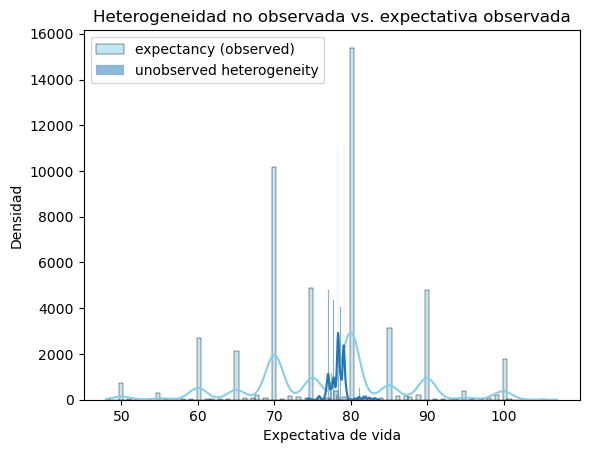

In [246]:

Xpred = cre.model.exog.dataframe.copy()
cols_to_zero = [
    'wage', 'edu', 'kids', 'exp', 'sistema', 'year', 'cronica', 'selfemp',
    'cotizando', 'hours', 'informal', 'mental', 'assets', 'region_3.0',
    'region_8.0', 'region_15.0', 'situation_2', 'missing_assets',
    'missing_sistema', 'missing_wage', 'missing_hours',
    'edu_mean', 'exp_mean', 'wage_mean', 'informal_mean', 'sistema_mean'  # incluir las agregadas si están
]

for col in cols_to_zero:
    if col in Xpred.columns:
        Xpred[col] = 0
yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="expectancy (observed)", kde=True)
sns.histplot(data=yhat, color="red", label="heterogenidad no observada", kde=True)

plt.legend()
plt.title("Heterogeneidad no observada vs. expectativa observada")
plt.xlabel("Expectativa de vida")
plt.ylabel("Densidad")
plt.show()


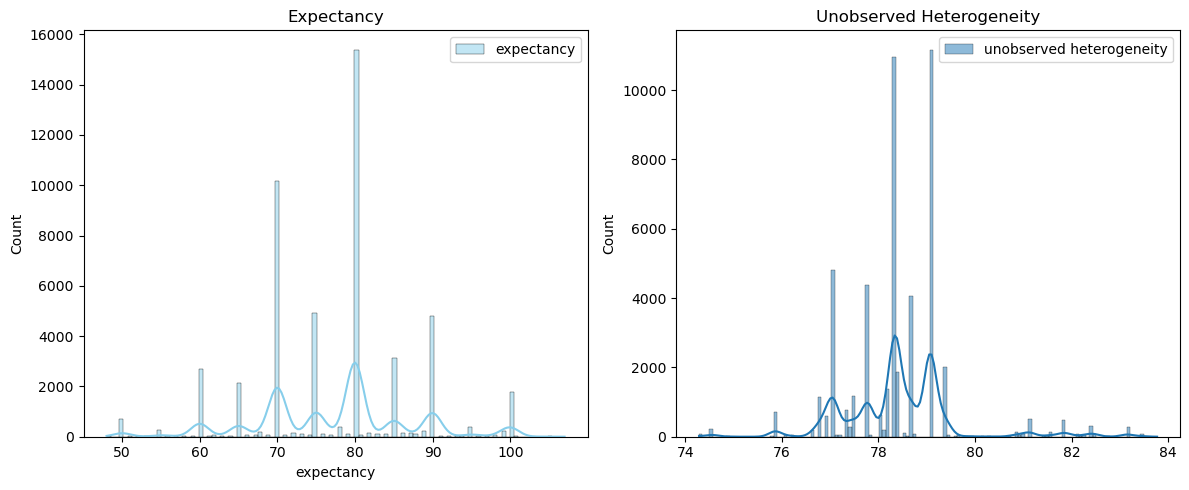

In [247]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=y, color="skyblue", label="expectativa", kde=True, ax=ax1)
ax1.set_title('Expectativa')
ax1.legend()

sns.histplot(data=yhat, color="red", label="heterogenidad no observada", kde=True, ax=ax2)
ax2.set_title('Heterogenidad no observada')
ax2.legend()

plt.tight_layout()
plt.show()


# Comparación de modelos

8.-Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

**R**: Si comparamos las atribcuiones de cada modelo, en este caso el mejor modelo conceptualmente es el CRE, ya que, permite capturar la heterogenidad no observable fija en el tiempo que claramente impacat la expectativa de vida. A diferencia del modelo de efectos fijos, la cual no permite estimar variables constantes, y del mdoelo de efectos aleatorios. Con respecto a las variables la que más se destacó es status_4, la cual identifica a la persona como viudo/a, dando un efecto positivo en la expectativa de vida, por otro lado la variable sistema afecta negativamente la expectativa de vida, es decir, estar en el sistema de AFP disminuye la expectativa de vida, otra variable que se destacó fue region_6, en la que indica que vivir en la Región de O'Higgins aumenta la expectativa de vida, entre otras variables. Cabe destcar que la variable crónica afecta positivamente la expectativa de vida en la mayoría de modelos, lo cual no tiene sentido, esto puede deverse a varios factores, por lo que debe de tenerse en cuenta.

In [249]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre, "Pooled": results}))

                                     Model Comparison                                    
                                    FE                RE               CRE         Pooled
-----------------------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects       PanelOLS
No. Observations                 49733             49733             49733          49710
Cov. Est.                       Robust            Robust            Robust     Unadjusted
R-squared                       0.0229            0.4232            0.4269         0.0488
R-Squared (Within)              0.0229            0.0105            0.0165         0.0055
R-Squared (Between)            -0.0176            0.0542            0.0501         0.0646
R-Squared (Overall)            -0.0019            0.0427            0.0410         0.0488
F-statisti